[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/cyneuro/Chapter_Colabs/blob/main/Colab_E.ipynb)

<details>
<summary><b>📖 Click to expand: Synaptic Variable Key & Module Roadmap</b></summary>

### Variable Key: Synaptic Parameters
| Symbol | NEURON Name | Definition | Units |
| :--- | :--- | :--- | :--- |
| **$E_{rev}$** | `syn.e` | Reversal Potential (Determines Excitation vs. Inhibition) | mV |
| **$\tau$** | `syn.tau` | Decay Time Constant (Synaptic kinetics/speed) | ms |
| **$w$** | `nc.weight[0]` | Synaptic Weight (Strength of the connection) | μS (approx) |
| **$\Delta t$** | `nc.delay` | Axonal Latency (Time for signal to travel) | ms |
| **ISI** | `ns.interval` | Inter-Stimulus Interval (Time between presynaptic spikes) | ms |

---

### Conceptual Glossary
* **Driving Force:** The difference between $V_m$ and $E_{rev}$. It determines the direction and magnitude of current flow.
* **Temporal Summation:** When multiple inputs arrive at the same synapse in quick succession, building upon one another.
* **Spatial Summation:** The integration of inputs arriving at different physical locations (e.g., proximal vs. distal dendrites).
* **Shunting Inhibition:** Inhibition that occurs near the resting potential; it "divides" excitability by increasing conductance without changing voltage.
* **Feedforward Inhibition:** A circuit motif where an excitatory signal also triggers a delayed inhibitory signal to narrow the integration window.

---

### Module Roadmap
* **E0** — Starter: Environment Setup
* **E1** — Excitatory Logic (AMPA-like)
* **E2** — Inhibitory Logic (GABA_A-like)
* **E3** — Dynamics Contrast (EPSP vs. IPSP)
* **E4** — Reversal Sweep (The Zero-Crossing)
* **E5** — Temporal Summation Logic
* **E6** — Spatial Summation & Dendritic Filtering
* **E7** — Feedforward Inhibition Motifs
* **E8** — Automated Signal Metrics
* **E9** — Synaptic Playground

</details>

## E0 — Starter: Environment Setup
> **Instruction:** In this section, we initialize the virtual laboratory. We establish a "Helper Function" (`mk_rec`) to act as our digital oscilloscope, allowing us to record voltage from any point on our virtual neuron.

### The Technical Environment
We use a standard **Hodgkin-Huxley (HH)** model for our sections. This ensures that even our "passive" experiments are grounded in a membrane that *could* spike if the stimulus is strong enough.
* **Resting Potential:** Calibrated to **-65mV**.
* **Recording:** We use `h.Vector()` to record both time (`t`) and voltage (`v`) at 0.1ms intervals.

In [1]:
#@title E0 — Starter: Environment Setup { display-mode: "form" }
!pip -q install neuron==8.2.4
try:
    from neuron import h, gui
except Exception:
    from neuron import h
from neuron.units import ms, mV
import numpy as np
import matplotlib.pyplot as plt

h.load_file('stdrun.hoc')

# --- Global Helpers ---

def psp_metrics(tvec, vtrace, baseline=(0, 5)):
    """Extracts biophysical features from a voltage trace without deprecation warnings."""
    tnp = np.array(tvec)
    vnp = np.array(vtrace)

    # Ensure arrays match in size
    if tnp.size != vnp.size:
        min_size = min(tnp.size, vnp.size)
        tnp = tnp[:min_size]
        vnp = vnp[:min_size]

    b = (tnp >= baseline[0]) & (tnp <= baseline[1])
    v0 = vnp[b].mean() if b.any() else vnp[0]

    v_rel = vnp - v0
    idx_peak = np.argmax(np.abs(v_rel))
    peak_val = v_rel[idx_peak]
    t_peak = tnp[idx_peak]

    # FIX: Using np.trapezoid instead of the deprecated np.trapz
    area = np.trapezoid(v_rel, tnp)

    return {'V0': v0, 'Peak': peak_val, 't_peak': t_peak, 'Area': area}

# Helper to create recordings and manage global time
t = h.Vector()
def mk_rec(sec):
    # Wipe the global time vector to ensure synchronization with voltage
    if t.size() > 0:
        t.resize(0)
    t.record(h._ref_t)

    v = h.Vector()
    v.record(sec(0.5)._ref_v)
    return v

print('E0 environment and automated metrics ready.')

E0 environment and automated metrics ready.


## E1 — Excitatory Logic: AMPA-like Synapse
**Goal:** Observe how a presynaptic spike (Neuron A) triggers a postsynaptic potential (Neuron B) via an excitatory chemical synapse.

### The Biophysical Mechanism
We are simulating an **AMPA-type glutamatergic synapse**. In the real brain, glutamate binds to AMPA receptors, opening a non-selective cation channel with a reversal potential ($E_{rev}$) of approximately **0mV**. Because 0mV is much more positive than the resting potential (-65mV), the resulting current flow is **inward**, causing the cell to depolarize.

### Student Exercises
1. **The Threshold Quest:** Use the sliders to find the exact `weight` where Neuron B transitions from a sub-threshold "bump" (EPSP) to firing its own Action Potential.
2. **Kinetic Influence:** Set the weight to 0.002. Move `tau` from 2.0 to 8.0. Describe how the **Area** of the signal changes even though the **Peak** remains relatively stable.
3. **Latency Check:** Using the zoomed plot, measure the time between the peak of the Blue spike and the start of the Red rise. Does this match your `delay` slider setting?

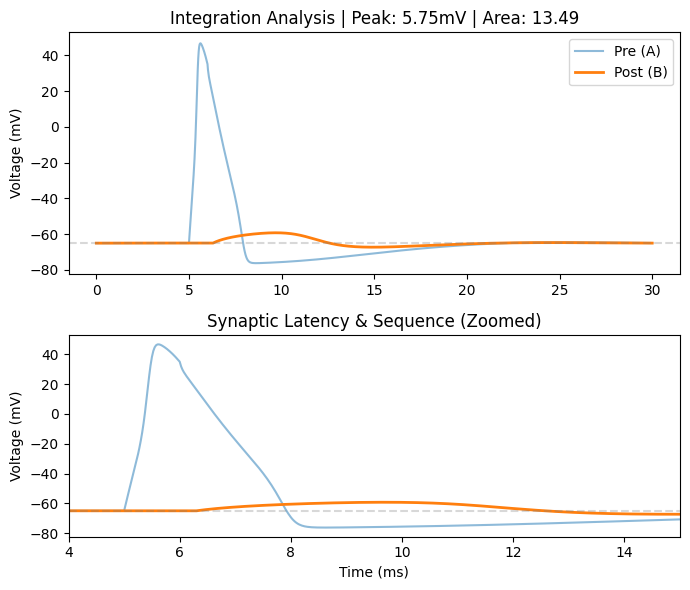

In [2]:
#@title E1 — Interactive Excitatory Logic { display-mode: "form" }
#@markdown Move sliders, then **click the Play button** to update the simulation.

weight = 0.001 #@param {type:"slider", min:0, max:0.01, step:0.0005}
tau = 2.0 #@param {type:"slider", min:0.5, max:10, step:0.5}
delay = 1.0 #@param {type:"slider", min:0.1, max:5, step:0.1}

# 1. Reset & Rebuild
h("forall delete_section()")
somaA = h.Section(name='somaA'); somaB = h.Section(name='somaB')
for s in [somaA, somaB]:
    s.L = s.diam = 20; s.insert('hh')

# 2. Setup Synapse (Excitatory)
syn = h.ExpSyn(somaB(0.5))
syn.tau = tau; syn.e = 0.0
nc = h.NetCon(somaA(0.5)._ref_v, syn, sec=somaA)
nc.threshold = -20; nc.delay = delay; nc.weight[0] = weight

# 3. Stimulus
iclamp = h.IClamp(somaA(0.5))
iclamp.delay = 5; iclamp.dur = 1; iclamp.amp = 2.0

# 4. Run Simulation
vA = mk_rec(somaA); vB = mk_rec(somaB)
h.finitialize(-65); h.continuerun(30)

# 5. Extract Metrics for Title
m = psp_metrics(t, vB)

# 6. Plotting (Single Figure, Two Panes)
plt.close('all')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), gridspec_kw={'height_ratios': [1.2, 1]})

# Top Plot: Global Integration
ax1.plot(t, vA, label='Pre (A)', color='C0', alpha=0.5)
ax1.plot(t, vB, label='Post (B)', color='C1', linewidth=2)
ax1.axhline(-65, color='gray', linestyle='--', alpha=0.3)
ax1.set_title(f"Integration Analysis | Peak: {m['Peak']:.2f}mV | Area: {m['Area']:.2f}")
ax1.set_ylabel("Voltage (mV)")
ax1.legend(loc='upper right')

# Bottom Plot: Zoomed Timing
ax2.plot(t, vA, color='C0', alpha=0.5)
ax2.plot(t, vB, color='C1', linewidth=2)
ax2.axhline(-65, color='gray', linestyle='--', alpha=0.3)
ax2.set_xlim(4, 15)
ax2.set_title("Synaptic Latency & Sequence (Zoomed)")
ax2.set_xlabel("Time (ms)"); ax2.set_ylabel("Voltage (mV)")

plt.tight_layout(); plt.show()

---
### Data Presentation & Reproducibility Check
* **Standardization:** Ensure your plots show the **Blue (Pre)** and **Red (Post)** traces clearly.
* **Baseline:** Why must we always indicate the -65mV resting potential when showing sub-threshold EPSPs?
* **Verification:** If you set `weight` to 0, does the Red trace stay perfectly flat? Why is this an important "negative control" for your model?

## E2 — Inhibitory Logic: GABA$_A$-like Synapse
**Goal:** Observe how a presynaptic spike triggers a hyperpolarizing **Inhibitory Post-Synaptic Potential (IPSP)**.

### The Biophysical Mechanism
We are now simulating a **GABA$_A$-type synapse**. In the central nervous system, GABA binds to receptors that open channels primarily permeable to **Chloride ($Cl^-$)**.
* **Reversal Potential ($E_{rev}$):** Typically around **-75mV**.
* **The Driving Force:** Since -75mV is more negative than the resting potential (-65mV), the opening of these channels pulls the membrane potential *downward* (hyperpolarization).

### Student Exercises
1. **The Polarity Shift:** Run the simulation with the default sliders. Why does the Red trace (Post-B) now go down instead of up?
2. **Kinetics of Inhibition:** Notice the default `tau_inh` is set to **8.0ms**. Compare this to the 2.0ms used in E1. How does this "slower" decay change the integration window for the neuron?
3. **The Shunt:** If you were to change the Resting Potential to -75mV (matching the reversal potential), what would happen to the voltage trace? Would the synapse still be "inhibitory"?

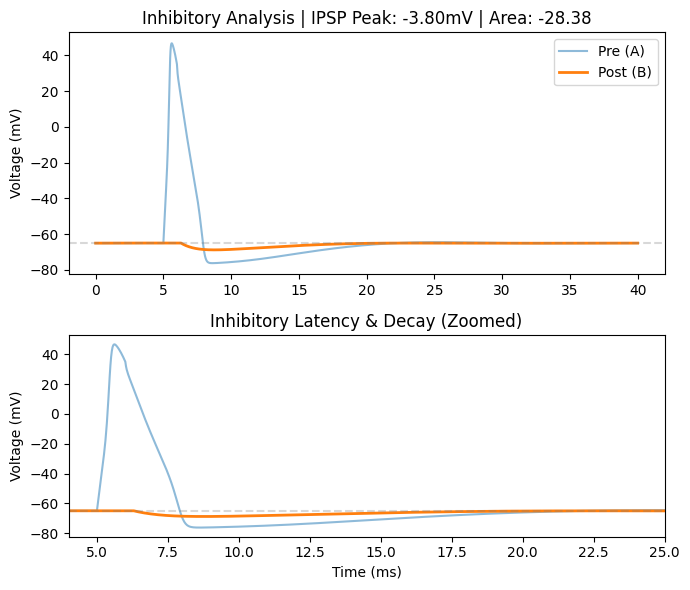

In [3]:
#@title E2 — Interactive Inhibitory Logic { display-mode: "form" }
#@markdown Move sliders to observe **Inhibitory** signaling. Note the change in $E_{rev}$ and $\tau$.

weight_inh = 0.006 #@param {type:"slider", min:0, max:0.05, step:0.001}
tau_inh = 8.0 #@param {type:"slider", min:1, max:20, step:1}
delay_inh = 1.0 #@param {type:"slider", min:0.1, max:5, step:0.1}

# 1. Reset & Rebuild
h("forall delete_section()")
somaA = h.Section(name='somaA'); somaB = h.Section(name='somaB')
for s in [somaA, somaB]:
    s.L = s.diam = 20; s.insert('hh')

# 2. Setup Synapse (Inhibitory: E_rev = -75mV)
syn = h.ExpSyn(somaB(0.5))
syn.tau = tau_inh
syn.e = -75.0

# 3. Connection
nc = h.NetCon(somaA(0.5)._ref_v, syn, sec=somaA)
nc.threshold = -20; nc.delay = delay_inh; nc.weight[0] = weight_inh

# 4. Trigger Spike in A
iclamp = h.IClamp(somaA(0.5))
iclamp.delay = 5; iclamp.dur = 1; iclamp.amp = 2.0

# 5. Run Simulation
vA = mk_rec(somaA); vB = mk_rec(somaB)
h.finitialize(-65); h.continuerun(40) # Slightly longer to see the slow decay

# 6. Extract Metrics
m = psp_metrics(t, vB)

# 7. Plotting (Consistent with E1)
plt.close('all')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), gridspec_kw={'height_ratios': [1.2, 1]})

# Top Plot: Global Integration
ax1.plot(t, vA, label='Pre (A)', color='C0', alpha=0.5)
ax1.plot(t, vB, label='Post (B)', color='C1', linewidth=2)
ax1.axhline(-65, color='gray', linestyle='--', alpha=0.3)
ax1.set_title(f"Inhibitory Analysis | IPSP Peak: {m['Peak']:.2f}mV | Area: {m['Area']:.2f}")
ax1.set_ylabel("Voltage (mV)")
ax1.legend(loc='upper right')

# Bottom Plot: Zoomed Timing
ax2.plot(t, vA, color='C0', alpha=0.5)
ax2.plot(t, vB, color='C1', linewidth=2)
ax2.axhline(-65, color='gray', linestyle='--', alpha=0.3)
ax2.set_xlim(4, 25) # Slightly wider window for the slower IPSP
ax2.set_title("Inhibitory Latency & Decay (Zoomed)")
ax2.set_xlabel("Time (ms)"); ax2.set_ylabel("Voltage (mV)")

plt.tight_layout(); plt.show()

---
### Inhibitory Analysis & Reproducibility
* **Polarity Check:** In the plots above, the Blue trace (Pre) goes UP while the Red trace (Post) goes DOWN. Based on the **Synaptic Variable Key**, why does a reversal potential ($E_{rev}$) of -75mV cause this downward deflection?
* **Integration Window:** Compare the **Area** of this IPSP to the EPSP from E1. Given that inhibitory kinetics (GABA) are often slower than excitatory ones (AMPA), how does this affect the duration of time the neuron is "suppressed" after a single input?
* **Reproducibility:** If you share this notebook with a peer, will they see the same -3.80mV peak? Identify the specific line in the **E0 — Starter** code that ensures every student starts from the same "baseline" voltage.

## E3 — Dynamics Contrast: EPSP vs. IPSP
**Goal:** Run a head-to-head comparison of excitatory and inhibitory signals to characterize their differences in temporal dynamics and magnitude.

### Why Compare?
In neural circuits, the "balance" of excitation and inhibition (E/I balance) is not just about voltage peaks; it is about **timing**.
* **Fast AMPA (Excitatory):** Optimized for speed and precision.
* **Slow GABA (Inhibitory):** Optimized for prolonged suppression and broad integration windows.

### Student Exercises
1. **Area Equalization:** Adjust the `weight` of the inhibitory synapse until its **Area** is approximately equal to the excitatory synapse. Even with equal areas, how do the "shapes" (peak and duration) differ?
2. **The Integration Window:** Looking at the results table, which synapse "controls" the neuron for a longer period of time?
3. **Temporal Precision:** If these two inputs arrived at the same time, which one would "win" the race to change the membrane potential first?


--- Comparative Metrics ---


,Condition,Peak (mV),t_peak (ms),Area
0,Excitatory (E1),103.451,8.70,95.874
1,Inhibitory (E2),-4.527,8.35,-36.229


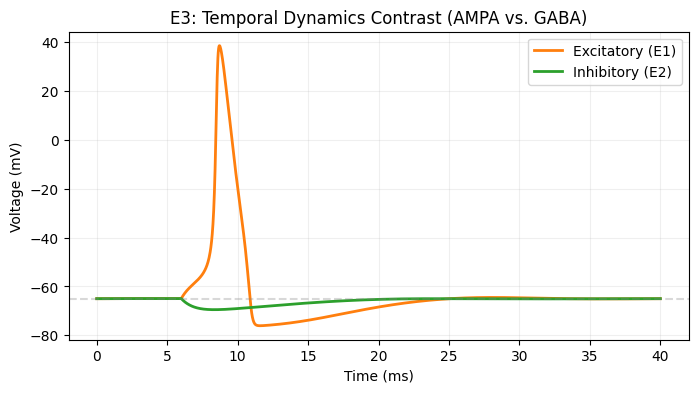

In [2]:
#@title E3 — EPSP vs IPSP: Comparative Analysis { display-mode: "form" }
import pandas as pd
import matplotlib.pyplot as plt

# 1. Permanent Setup (Outside the loop to prevent crashes)
h("forall delete_section()")
s_comp = h.Section(name='s_comp')
s_comp.L = s_comp.diam = 20
s_comp.insert('hh')

syn_comp = h.ExpSyn(s_comp(0.5))
ns_comp = h.NetStim()
ns_comp.number = 1
ns_comp.start = 5

nc_comp = h.NetCon(ns_comp, syn_comp)
nc_comp.delay = 1

# Record once
v_comp = mk_rec(s_comp)

def run_stable_trial(name, e_rev, tau, weight, color):
    # Update existing objects instead of creating new ones
    syn_comp.e = e_rev
    syn_comp.tau = tau
    nc_comp.weight[0] = weight

    h.finitialize(-65)
    h.continuerun(40)

    # Capture a snapshot of the metrics and trace
    m = psp_metrics(t, v_comp)
    return {
        'Condition': name,
        'Peak (mV)': m['Peak'],
        't_peak (ms)': m['t_peak'],
        'Area': m['Area'],
        'v_data': list(v_comp),
        'color': color
    }

# 2. Execution
results = []
results.append(run_stable_trial("Excitatory (E1)", 0.0, 2.0, 0.002, 'C1'))
results.append(run_stable_trial("Inhibitory (E2)", -75.0, 8.0, 0.008, 'C2'))

# 3. Display Table
df = pd.DataFrame(results)[['Condition', 'Peak (mV)', 't_peak (ms)', 'Area']]
print("\n--- Comparative Metrics ---")
display(df.round(3))

# 4. Plot Comparison
plt.figure(figsize=(8, 4))
for r in results:
    plt.plot(t, r['v_data'], label=r['Condition'], color=r['color'], linewidth=2)
plt.axhline(-65, color='gray', linestyle='--', alpha=0.3)
plt.title("E3: Temporal Dynamics Contrast (AMPA vs. GABA)")
plt.xlabel("Time (ms)"); plt.ylabel("Voltage (mV)")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

---
### E3: The E/I Balance Reflection
*To be completed after reviewing the Comparative Metrics table.*

#### 1. Kinetic Disparity
Based on your results, the **t_peak** for the Inhibitory (E2) synapse is significantly later than the Excitatory (E1) synapse. How does this "slow" inhibition provide a window for excitation to trigger a spike before being suppressed?
> **Answer:** #### 2. The Power of Area
Notice the **Area** metric. A synapse can have a small **Peak** but a large **Area** if its decay ($\tau$) is long. In terms of "total charge" moved across the membrane, which synapse in your current table has a greater overall impact on the cell's excitability?
> **Answer:** #### 3. Predict the Sum
If both these synapses fired at the exact same time ($t=5ms$), would the resulting voltage trace be a simple subtraction of the two? Why or why not? (*Hint: Think about the non-linear nature of the Hodgkin-Huxley membrane.*)
> **Answer:** ```

---

### **Next Step: E4 — The Reversal Sweep**
I noticed in the [latest screenshot](https://colab.research.google.com/drive/1WE8TUKGOOdjsKdwvnNIGdpiKv7DGryCs#scrollTo=957b0fa2) that your **E4** section currently has a different coding style (using a list of values in a `for` loop) compared to the interactive slider versions we built for E1 and E2.

**Would you like me to provide the "Interactive Sweep" version of E4 that uses sliders for the range, matching the layout of the previous sections?**

## E4 — Reversal Sweep: Finding the "Null Point"
**Goal:** Systematically sweep the Synaptic Reversal Potential ($E_{rev}$) to visualize how the "Driving Force" determines the polarity and magnitude of the post-synaptic response.

### The Concept of Shunting
When $E_{rev}$ is equal to the Resting Potential (**-65mV**), the driving force is zero. The synapse is neither excitatory nor inhibitory in terms of voltage—the trace will remain perfectly flat. However, the synapse is still "active" because it has increased the membrane's conductance. This is known as **Shunting Inhibition**, as it "shunts" (bypasses) other inputs.

### Student Exercises
1. **The Zero-Crossing:** Adjust the sliders to find the exact $E_{rev}$ value where the peak amplitude of the PSP becomes zero. How does this value relate to your resting membrane potential?
2. **Polarity Flip:** As you move $E_{rev}$ from -80mV to -40mV, observe the transition. Does the **t_peak** change significantly as the signal flips from a dip to a bump?
3. **The Shunt:** Set $E_{rev}$ to -65mV. Notice there is no voltage change. Why is this synapse still considered "inhibitory" if it doesn't change the voltage?

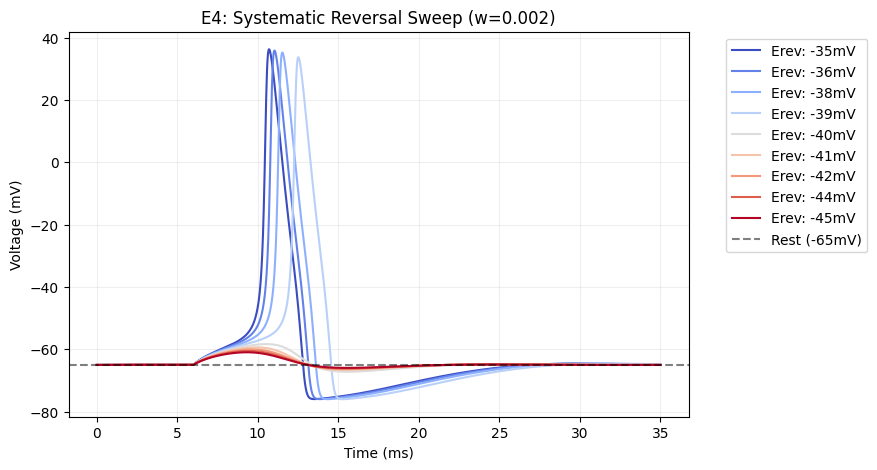

In [4]:
#@title E4 — The Reversal Sweep { display-mode: "form" }
#@markdown Sweep $E_{rev}$ to observe the transition from Hyperpolarization to Depolarization.

e_min = -35 #@param {type:"slider", min:-100, max:0, step:5}
e_max = -45 #@param {type:"slider", min:-100, max:0, step:5}
weight = 0.002 #@param {type:"slider", min:0, max:0.01, step:0.001}

# 1. Stable Setup (Reuse objects to prevent crashes)
h("forall delete_section()")
s_sweep = h.Section(name='s_sweep'); s_sweep.L = s_sweep.diam = 20; s_sweep.insert('hh')
syn_sweep = h.ExpSyn(s_sweep(0.5)); syn_sweep.tau = 5.0
ns_sweep = h.NetStim(); ns_sweep.number = 1; ns_sweep.start = 5
nc_sweep = h.NetCon(ns_sweep, syn_sweep); nc_sweep.delay = 1; nc_sweep.weight[0] = weight
v_sweep = mk_rec(s_sweep)

# 2. Execution of Sweep
sweep_vals = np.linspace(e_min, e_max, 9)
plt.close('all')
plt.figure(figsize=(8, 5))

for e_val in sweep_vals:
    syn_sweep.e = e_val
    h.finitialize(-65)
    h.continuerun(35)

    # Map color: Blue (Hyperpolarizing) to Red (Depolarizing)
    color = plt.cm.coolwarm((e_val - e_min) / (e_max - e_min))
    plt.plot(t, v_sweep, color=color, label=f"Erev: {e_val:.0f}mV", linewidth=1.5)

# 3. Formatting
plt.axhline(-65, color='black', linestyle='--', alpha=0.5, label="Rest (-65mV)")
plt.title(f"E4: Systematic Reversal Sweep (w={weight})")
plt.xlabel("Time (ms)"); plt.ylabel("Voltage (mV)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

---
### E4: Reversal Potential Review
* **Zero-Crossing:** Confirm that the "flat" trace occurs at -65mV. This is your biophysical "null point."
* **Driving Force:** Recall the equation $I_{syn} = g_{syn}(V_m - E_{rev})$. When $V_m$ is more positive than $E_{rev}$, the current is outward (inhibitory). When $V_m$ is more negative than $E_{rev}$, the current is inward (excitatory).
* **Next Prediction:** In **E5**, we will fire *two* spikes in quick succession. If the first spike doesn't reach threshold, can the second one "stand on its shoulders" to trigger an action potential?

## E5 — Temporal Summation: The "Shoulder" Effect
**Goal:** Observe how the interval between two presynaptic spikes (Inter-Stimulus Interval or **ISI**) determines the final peak of the postsynaptic response.

### The Biophysical Window
When a second spike arrives before the first EPSP has returned to baseline, the second EPSP "stands on the shoulders" of the first. This is **Temporal Summation**. The efficiency of this process depends on:
* **The Membrane Time Constant ($\tau_m$):** How long the cell "remembers" the voltage change.
* **The Synaptic Time Constant ($\tau_{syn}$):** How long the conductance remains open.

### Student Exercises
1. **The Integration Limit:** Set the ISI to 20ms. Do the two peaks interact at all? Find the "Critical ISI" where the two peaks begin to merge into one single, larger wave.
2. **Saturation:** Set the `weight` high enough that a single spike nearly reaches 0mV. Notice that the second spike doesn't add as much voltage as the first. This is **Sublinear Summation** caused by a reduction in driving force.
3. **Kinetics:** Increase `tau` to 10ms. How does this change the "Temporal Window" in which the two spikes can summate?

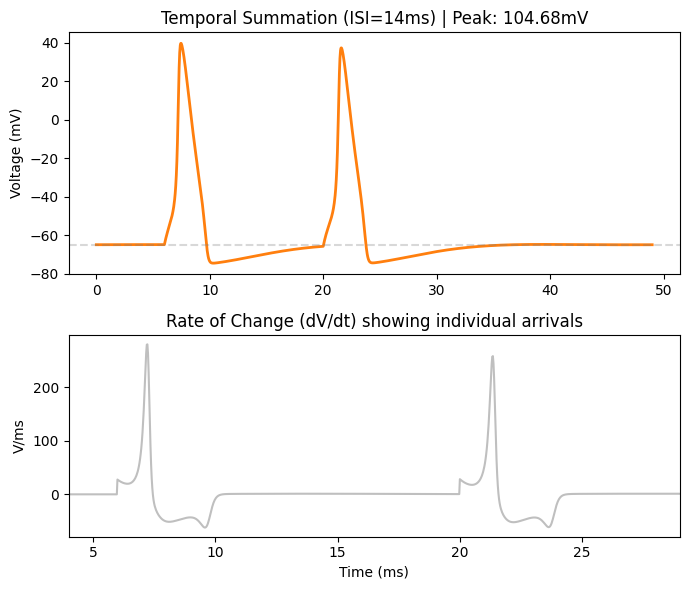

In [6]:
#@title E5 — Temporal Summation Logic { display-mode: "form" }

isi = 14 #@param {type:"slider", min:1, max:30, step:1}
tau = 5 #@param {type:"slider", min:0.5, max:10, step:0.5}
weight = 0.0055 #@param {type:"slider", min:0, max:0.01, step:0.0005}

# 1. Clear memory and rebuild
h("forall delete_section()")
s_sum = h.Section(name='s_sum')
s_sum.L = s_sum.diam = 20
s_sum.insert('hh')

syn_sum = h.ExpSyn(s_sum(0.5))
syn_sum.e = 0
syn_sum.tau = tau

ns_sum = h.NetStim()
ns_sum.number = 2
ns_sum.start = 5
ns_sum.interval = isi

nc_sum = h.NetCon(ns_sum, syn_sum)
nc_sum.delay = 1
nc_sum.weight[0] = weight

# Record
v_sum = mk_rec(s_sum)

# 2. Run
h.finitialize(-65)
h.continuerun(15 + isi + 20)

# 3. Metrics & Plotting
m = psp_metrics(t, v_sum)
plt.close('all')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), gridspec_kw={'height_ratios': [1.2, 1]})

# Convert to numpy to avoid TypeError in slicing
t_np = np.array(t)
v_np = np.array(v_sum)

# Top: Global View
ax1.plot(t_np, v_np, color='C1', linewidth=2, label='Post-synaptic (B)')
ax1.axhline(-65, color='gray', linestyle='--', alpha=0.3)
ax1.set_title(f"Temporal Summation (ISI={isi}ms) | Peak: {m['Peak']:.2f}mV")
ax1.set_ylabel("Voltage (mV)")

# Bottom: Derivative (dV/dt) - Now using numpy arrays for slicing
dv = np.diff(v_np) / np.diff(t_np)
ax2.plot(t_np[:-1], dv, color='gray', alpha=0.5)
ax2.set_title("Rate of Change (dV/dt) showing individual arrivals")
ax2.set_xlabel("Time (ms)"); ax2.set_ylabel("V/ms")
ax2.set_xlim(4, 15 + isi)

plt.tight_layout(); plt.show()

---
### E5: Temporal Summation Review
* **The "Shoulder" Effect:** When the ISI is short (e.g., < 10ms), the second EPSP begins before the first has finished. This stacking effect is the primary way a single synapse can drive a neuron toward threshold.
* **Non-linearity:** As the membrane potential gets closer to the reversal potential (0mV), each subsequent spike contributes *less* voltage. This is because the **Driving Force** ($V_m - E_{rev}$) is decreasing.
* **dV/dt Analysis:** Even when the voltage traces look merged, the derivative plot reveals the exact moment each "packet" of neurotransmitter arrived.

## E6 — Spatial Summation & Dendritic Filtering
**Goal:** Quantify how the electrotonic distance of a synapse affects somatic integration.

### The Passive Cable Effect
Dendrites are not perfect wires; they have internal resistance ($R_a$) and "leaky" membranes ($g_{pas}$). As a signal travels from a distant (distal) dendrite toward the soma, it undergoes **Dendritic Filtering**.

### Predict → Verify
Before running the code, record your predictions in the "Student Answer" sections:
1. **Attenuation:** If the distal synapse is at the far end of the dendrite, will the somatic peak be $>50\%$ or $<50\%$ of the proximal peak?
   * *Student Answer:* 2. **Temporal Smearing:** Will the time-to-peak ($t_{peak}$) for the distal input be *earlier* or *later* than the proximal input?
   * *Student Answer:* 3. **Summation:** Will the combined peak (Both) be exactly equal to the sum of the individual peaks (Linear) or smaller (Sublinear)?
   * *Student Answer:* ### 📑 What to Change:
* **`distal_loc`**: Moves the green synapse along the dendrite (0.1 = proximal, 0.9 = distal).
* **`dend_diam`**: Changes the length constant ($\lambda$) by altering internal resistance.
* **`weight`**: Adjusts the synaptic strength for both inputs.

### Student Exercises
1. **The Distance Tax:** Run the simulation for the Proximal input only, then the Distal input only. By what percentage does the somatic peak amplitude drop at your current `distal_loc`?
2. **Speed vs. Distance:** Observe the **t_peak**. Why does the distal signal arrive at the soma later and appear "smeared" (wider) compared to the proximal one?
3. **Diameter Impact:** Set `distal_loc` to 0.9. Now change `dend_diam` from 1.0 to 4.0. How does the "thickness" of the dendrite affect the signal's ability to reach the soma?

---
### E6: Model Validation & Sanity Checks
* **Attenuation Check:** Does the peak amplitude decrease monotonically as `distal_loc` increases? If not, verify that `dendB` is correctly connected to `somaB`.
* **Summation Check:** Calculate `(Peak_Both - Baseline)`. Is it exactly equal to `(Peak_Prox + Peak_Distal - 2*Baseline)`?
    * If it is less, you are observing **Sublinear Summation**.
* **Physics Check:** Does increasing `dend_diam` reduce the attenuation? (Recall that a wider dendrite has lower internal resistance $R_a$).

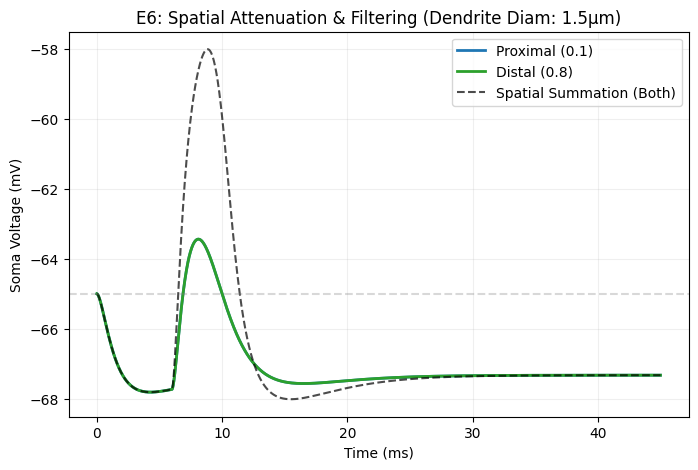

In [2]:
#@title E6 — Spatial Summation Logic { display-mode: "form" }

distal_loc = 0.8 #@param {type:"slider", min:0.1, max:0.95, step:0.05}
dend_diam = 1.5 #@param {type:"slider", min:0.1, max:5.0, step:0.1}
weight = 0.005 #@param {type:"slider", min:0, max:0.02, step:0.001}

# 1. Persistent Setup (Wipe old sections to keep memory clean)
h("forall delete_section()")
somaB = h.Section(name='somaB'); somaB.L = somaB.diam = 20; somaB.insert('hh')
dendB = h.Section(name='dendB'); dendB.L = 500; dendB.diam = dend_diam; dendB.insert('pas')
dendB.connect(somaB(1))

# 2. Rebuild Synapses
synP = h.ExpSyn(dendB(0.1)) # Proximal
synD = h.ExpSyn(dendB(distal_loc)) # Distal
for s in [synP, synD]: s.e = 0; s.tau = 2.0

# Trigger both at t=5ms
ns = h.NetStim(); ns.number = 1; ns.start = 5
ncP = h.NetCon(ns, synP); ncP.weight[0] = weight; ncP.delay = 1
ncD = h.NetCon(ns, synD); ncD.weight[0] = weight; ncD.delay = 1

# 3. Record from Soma
v_soma = mk_rec(somaB)

# 4. Multi-trial Execution
def run_spatial(wp, wd):
    ncP.weight[0] = wp; ncD.weight[0] = wd
    h.finitialize(-65); h.continuerun(45)
    return np.array(v_soma)

vp_data = run_spatial(weight, 0)
vd_data = run_spatial(0, weight)
vboth_data = run_spatial(weight, weight)
t_np = np.array(t)

# 5. Plotting
plt.close('all')
plt.figure(figsize=(8, 5))
plt.plot(t_np, vp_data, label='Proximal (0.1)', color='C0', linewidth=2)
plt.plot(t_np, vd_data, label=f'Distal ({distal_loc})', color='C2', linewidth=2)
plt.plot(t_np, vboth_data, label='Spatial Summation (Both)', color='black', linestyle='--', alpha=0.7)
plt.axhline(-65, color='gray', linestyle='--', alpha=0.3)
plt.title(f"E6: Spatial Attenuation & Filtering (Dendrite Diam: {dend_diam}µm)")
plt.xlabel("Time (ms)"); plt.ylabel("Soma Voltage (mV)")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

### Student Exercises
1. **The Distance Tax:** Run the simulation for the Proximal input only, then the Distal input only. By what percentage does the somatic peak amplitude drop at your current `distal_loc`?
2. **Speed vs. Distance:** Observe the **t_peak**. Why does the distal signal arrive at the soma later and appear "smeared" (wider) compared to the proximal one?
3. **Diameter Impact:** Set `distal_loc` to 0.9. Now change `dend_diam` from 1.0 to 4.0. How does the "thickness" of the dendrite affect the signal's ability to reach the soma?

---
### E6: Model Validation & Sanity Checks
* **Attenuation Check:** Does the peak amplitude decrease monotonically as `distal_loc` increases? If not, verify that `dendB` is correctly connected to `somaB`.
* **Summation Check:** Calculate `(Peak_Both - Baseline)`. Is it exactly equal to `(Peak_Prox + Peak_Distal - 2*Baseline)`?
    * If it is less, you are observing **Sublinear Summation**.
* **Physics Check:** Does increasing `dend_diam` reduce the attenuation? (Recall that a wider dendrite has lower internal resistance $R_a$).

## E7 — Feedforward Inhibition (E→I)
**Goal:** Observe how a fast EPSP followed by a delayed IPSP acts to "clamp" the voltage peak and significantly narrow the integration window for the postsynaptic neuron. This circuit motif allows for precise timing control without necessarily reducing the initial excitatory amplitude.

### The Circuit Motif
In this motif, an extrinsic input excites both a principal neuron and an inhibitory interneuron. This creates a "race" where the EPSP starts first, but is quickly truncated by a delayed IPSP.

### Predict → Verify
* **Window Narrowing:** A smaller $\Delta t$ (inhibition closer to excitation) results in a reduced peak and an earlier return to baseline.
* **Excitability:** Spike probability decreases significantly even if the EPSP onset remains unchanged, as the "window of opportunity" to reach threshold is shortened.

### What to Change:
* **Synaptic Weights:** Adjust `ncE.weight[0]` (excitatory) and `ncI.weight[0]` (inhibitory).
* **Timing:** Change the start time of the inhibitory stimulus relative to the excitatory one ($\Delta t = nsI.start - nsE.start$).
* **Inhibitory Kinetics:** Modify the inhibitory time constant (`synI.tau`).

### Sanity Checks
* **Metric Sweep:** For several $\Delta t$ values, compute the peak voltage, latency, and total area of the postsynaptic response.
* **Clamping Observation:** Show that as the inhibitory input approaches the excitatory input in time (smaller $\Delta t$), the voltage peak is monotonically clamped at lower levels.

### Student Exercises
#### 1. Clamping Sensitivity
**Plot the Peak Voltage vs. $\Delta t$.**
* Identify and mark the specific $\Delta t$ at which the excitatory peak is reduced by **50%** compared to a purely excitatory control.

#### 2. Kinetic Influence on Integration
**Keep $\Delta t$ fixed and vary the inhibitory time constant ($\tau$).**
* **Explain:** Describe the differences in how "tightly" the voltage is clamped and how the decay phase of the PSP changes as inhibition becomes slower or faster.

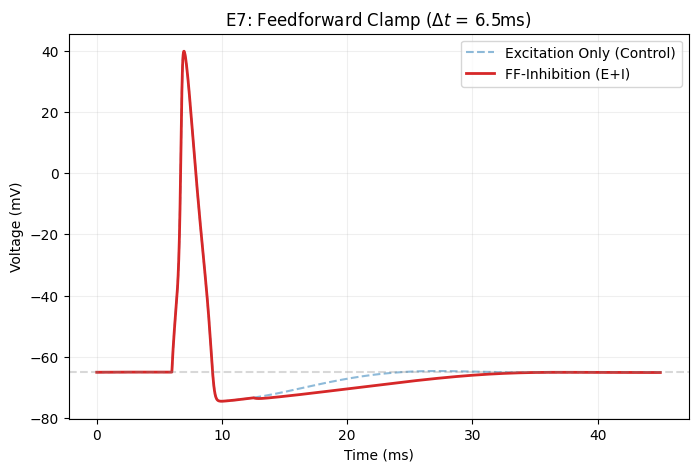

In [8]:
#@title E7 — Feedforward Inhibition Logic { display-mode: "form" }

delta_t = 6.5 #@param {type:"slider", min:1, max:15, step:0.5}
weight_exc = 0.017 #@param {type:"slider", min:0, max:0.02, step:0.001}
weight_inh = 0.019 #@param {type:"slider", min:0, max:0.03, step:0.001}
tau_inh = 8.0 #@param {type:"slider", min:1, max:20, step:1}

# 1. Stable Setup
h("forall delete_section()")
somaB = h.Section(name='somaB'); somaB.L = somaB.diam = 20; somaB.insert('hh')

# 2. Synapses
synE = h.ExpSyn(somaB(0.5)); synE.e = 0; synE.tau = 2.0
synI = h.ExpSyn(somaB(0.5)); synI.e = -75; synI.tau = tau_inh

# 3. Stimulators
nsE = h.NetStim(); nsE.number = 1; nsE.start = 5
nsI = h.NetStim(); nsI.number = 1; nsI.start = 5 + delta_t

ncE = h.NetCon(nsE, synE); ncE.weight[0] = weight_exc; ncE.delay = 1
ncI = h.NetCon(nsI, synI); ncI.weight[0] = weight_inh; ncI.delay = 1

v_ff = mk_rec(somaB)

# 4. Multi-trial Execution
def run_ff(we, wi):
    ncE.weight[0] = we; ncI.weight[0] = wi
    h.finitialize(-65); h.continuerun(45)
    return np.array(v_ff)

ve_only = run_ff(weight_exc, 0)
v_combo = run_ff(weight_exc, weight_inh)
t_np = np.array(t)

# 5. Plotting (Fixed Syntax)
plt.close('all')
plt.figure(figsize=(8, 5))
plt.plot(t_np, ve_only, 'C0--', label='Excitation Only (Control)', alpha=0.5)
plt.plot(t_np, v_combo, 'C3', label='FF-Inhibition (E+I)', linewidth=2)
plt.axhline(-65, color='gray', linestyle='--', alpha=0.3)

# Combined f-string and raw string for the Delta symbol
plt.title(fr"E7: Feedforward Clamp ($\Delta t$ = {delta_t}ms)")

plt.xlabel("Time (ms)"); plt.ylabel("Voltage (mV)")
plt.legend(); plt.grid(True, alpha=0.2)
plt.show()

### E7: Sanity Checks
* **Metric Sweep:** For several $\Delta t$ values, compute the peak voltage, latency, and total area of the postsynaptic response.
* **Clamping Observation:** Show that as the inhibitory input approaches the excitatory input in time (smaller $\Delta t$), the voltage peak is monotonically clamped at lower levels.

### Student Exercises
#### 1. Clamping Sensitivity
**Plot the Peak Voltage vs. $\Delta t$.**
* Identify and mark the specific $\Delta t$ at which the excitatory peak is reduced by **50%** compared to a purely excitatory control.

#### 2. Kinetic Influence on Integration
**Keep $\Delta t$ fixed and vary the inhibitory time constant ($\tau$).**
* **Explain:** Describe the differences in how "tightly" the voltage is clamped and how the decay phase of the PSP changes as inhibition becomes slower or faster.

## E8 — Analysis: Latency, Peak, and Area
**Idea:** Provide a minimal, reusable metrics function to automatically extract key signal features such as the baseline voltage ($V_0$), peak amplitude ($V_{peak}$), time-to-peak ($t_{peak}$), and the total area under the curve (integral).

### Predict → Verify
1. **Area vs. Peak:** If inhibition narrows the EPSP but doesn't change the initial slope, will the *Peak* or the *Area* show a larger percentage decrease?
   * *Student Answer:*
2. **Latency:** Does adding inhibition shift the *measured* $t_{peak}$ of the EPSP earlier or later?
   * *Student Answer:*

### What to Change:
* **Baseline Window:** Adjust the time range used to calculate the reference $V_0$ in the `psp_metrics` function.
* **Detection Thresholds:** Modify the criteria used to identify the start and end of a synaptic event for area calculations.

### Model Validation
* **Validation Run:** Execute the helper function on the most recent simulation trace.
* **Verification:** Confirm that the output units (e.g., mV, ms) are correct and that the signs (positive for EPSPs, negative for IPSPs) match the visual data.

### Exercises
#### 1. Expanding the Toolkit
Update the metrics function to include two additional calculations:
* **Half-width:** The duration of the signal at 50% of its peak amplitude.
* **10-90% Rise Time:** The time it takes for the signal to transition from 10% to 90% of its peak.
* **Compare:** Use these new metrics to quantify the specific differences between a standard EPSP and a standard IPSP from your earlier simulations.

--- Automated Synaptic Analysis ---


,Metric,Exc Only (Control),E + I (Clamped)
0,Baseline (V0),-64.96,-64.96
1,Peak Amp (mV),104.75,104.75
2,t_peak (ms),6.98,6.98
3,Total Area,99.56,53.73


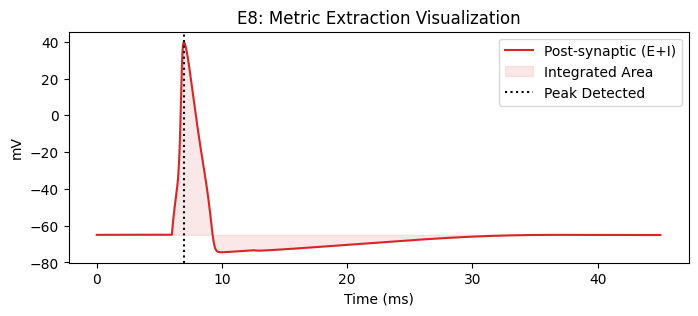

In [9]:
#@title E8 — Run Automated Metrics { display-mode: "form" }
import pandas as pd

# 1. Extract metrics using the helper from E0
# We analyze the traces generated in E7
m_e = psp_metrics(t_np, ve_only)
m_c = psp_metrics(t_np, v_combo)

# 2. Display as a Table
df = pd.DataFrame({
    "Metric": ["Baseline (V0)", "Peak Amp (mV)", "t_peak (ms)", "Total Area"],
    "Exc Only (Control)": [f"{m_e['V0']:.2f}", f"{m_e['Peak']:.2f}", f"{m_e['t_peak']:.2f}", f"{m_e['Area']:.2f}"],
    "E + I (Clamped)": [f"{m_c['V0']:.2f}", f"{m_c['Peak']:.2f}", f"{m_c['t_peak']:.2f}", f"{m_c['Area']:.2f}"]
})

print("--- Automated Synaptic Analysis ---")
display(df)

# 3. Visual Validation Plot
plt.figure(figsize=(8, 3))
plt.plot(t_np, v_combo, color='C3', label='Post-synaptic (E+I)')
plt.fill_between(t_np, -65, v_combo, color='C3', alpha=0.1, label='Integrated Area')
plt.axvline(m_c['t_peak'], color='black', linestyle=':', label='Peak Detected')
plt.title("E8: Metric Extraction Visualization")
plt.legend(); plt.xlabel("Time (ms)"); plt.ylabel("mV"); plt.show()

### E8: Model Validation
* **Validation Run:** Execute the helper function on the most recent simulation trace to verify the alignment of detection markers.
* **Verification:** Confirm that the output units (e.g., mV, ms) are correct and that the signs (positive for EPSPs, negative for IPSPs) match the visual data.
* **Peak Alignment:** Ensure the vertical "Peak Detected" line aligns perfectly with the highest point of the voltage trace.

### Exercises
#### 1. Expanding the Toolkit
Update the `psp_metrics` function (or create a new analysis block) to include two additional calculations:
* **Half-width:** The duration of the signal (in ms) at 50% of its peak amplitude.
* **10-90% Rise Time:** The time it takes for the signal to transition from 10% to 90% of its peak.
* **Compare:** Use these new metrics to quantify the specific differences between a standard EPSP and a standard IPSP from your earlier simulations.

#### 2. Percentage Analysis
* **Inhibitory Impact:** Use the automated table to calculate the percentage reduction in **Total Area** caused by the feedforward inhibition in E7.
* **Discussion:** Is the reduction in **Area** more or less significant than the reduction in **Peak Amplitude**? Why might the area be a better measure of "total synaptic drive"?

## E9 — Synaptic Playground
**Idea:** Free exploration. Systematically vary synaptic parameters to practice **Predict → Verify** reasoning. This section is designed to test your intuition about how electrochemical gradients and channel kinetics shape the post-synaptic response.

### What to Change:
* **Synaptic Identity:** Reversal potential ($E_{rev}$).
* **Temporal Profile:** Decay time constant ($\tau$).
* **Strength:** Synaptic weight ($w$).
* **Timing:** Axonal or stimulus delay.
* **Documentation:** Record the specific parameter tuple used for every run.

### Model Validation
For every experimental configuration, consistently record and verify the following metrics:
* **Baseline voltage ($V_0$)**
* **Peak amplitude ($V_{peak}$)**
* **Latency to peak ($t_{peak}$)**
* **Total area (integral)**

### Exercises
#### 1. Predict → Verify Log
Perform three distinct "custom" runs. For each, write down your prediction of the change (e.g., "Increasing $\tau$ while decreasing weight will result in a wider but shorter PSP") before executing the code.

* **Run 1:** [Parameters] -> [Prediction] -> [Result]
* **Run 2:** [Parameters] -> [Prediction] -> [Result]
* **Run 3:** [Parameters] -> [Prediction] -> [Result]

#### 2. The "Ultimate Clamp" Challenge
Find a combination of $E_{rev}$, $Weight$, and $Tau$ that allows you to maintain the membrane potential within **1mV** of the resting potential, even when a massive excitatory weight (0.05) is applied. What does this tell you about the power of shunting inhibition?

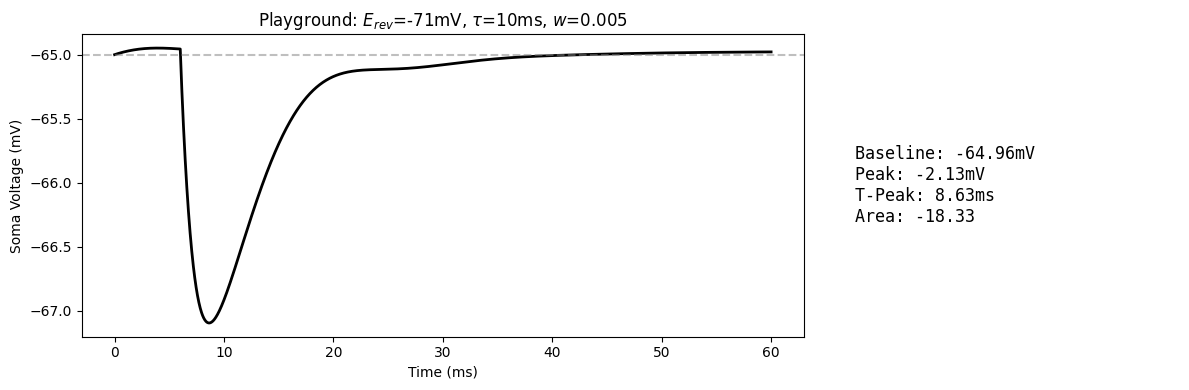

In [4]:
#@title E9 — Synaptic Playground Master Controller { display-mode: "form" }

e_rev = -71 #@param {type:"slider", min:-90, max:20, step:1}
tau = 10 #@param {type:"slider", min:1, max:50, step:1}
weight = 0.005 #@param {type:"slider", min:0, max:0.05, step:0.001}
delay = 1 #@param {type:"slider", min:1, max:20, step:0.5}

# 1. Setup Environment
h("forall delete_section()")
soma_p = h.Section(name='soma_p'); soma_p.L = soma_p.diam = 20; soma_p.insert('hh')

# 2. Universal Synapse
syn = h.ExpSyn(soma_p(0.5))
syn.e = e_rev
syn.tau = tau

ns = h.NetStim(); ns.number = 1; ns.start = 5
nc = h.NetCon(ns, syn); nc.weight[0] = weight; nc.delay = delay

v_rec = mk_rec(soma_p)

# 3. Execution
h.finitialize(-65)
h.continuerun(60)
t_np = np.array(t); v_np = np.array(v_rec)

# 4. Automated Analysis
m = psp_metrics(t_np, v_np)

# 5. Plotting & Results
plt.close('all')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [2, 1]})

ax1.plot(t_np, v_np, color='black', linewidth=2)
ax1.axhline(-65, color='gray', linestyle='--', alpha=0.5)
ax1.set_title(fr"Playground: $E_{{rev}}$={e_rev}mV, $\tau$={tau}ms, $w$={weight}")
ax1.set_xlabel("Time (ms)"); ax1.set_ylabel("Soma Voltage (mV)")

# Summary Table on Plot
stats_text = (f"Baseline: {m['V0']:.2f}mV\n"
              f"Peak: {m['Peak']:.2f}mV\n"
              f"T-Peak: {m['t_peak']:.2f}ms\n"
              f"Area: {m['Area']:.2f}")
ax2.axis('off')
ax2.text(0.1, 0.5, stats_text, fontsize=12, family='monospace', verticalalignment='center')

plt.tight_layout()
plt.show()

### Reflection
* **Parameter Interaction:** How do $E_{syn}$ and $\tau$ jointly control PSP amplitude and timing?
* **Inhibitory Polarity:** When does inhibitory input look depolarizing yet stay functionally inhibitory?
* **Summation Dynamics:** How do ISI and electrotonic distance interact in postsynaptic integration?

---

### Practice / Discussion Questions — Set B — Biology → Model Mapping
1. **Model Abstraction:** Define a model abstraction for a neuron that preserves interpretability: which parameters must be in **biophysical units**, and why?
2. **Compositionality:** Explain how **blocks** (RC membrane, synaptic conductance, spike generator) can be composed into a testable single-cell model.
3. **Model Selection:** Justify what's gained and lost when moving from detailed HH-type to reduced spiking models?
4. **Documentation:** How do you **document assumptions** so a reader can reproduce and critique your model? (List 3–4 items.)
5. **Validation:** What's a **model validation** check for a synapse implemented with a fixed reversal potential? (Describe the test and expected result.)

## Practice / Discussion Questions — Set B — Biology → Model Mapping
*Instruction: Use your observations from E1–E9 to justify your answers.*

1. **Parameter Interpretability:** In E9, you changed $E_{rev}$ and $\tau$. Why is it essential for an educational model to keep these in biophysical units (mV, ms) rather than arbitrary "strength" scores?
2. **The "Shunt" Logic:** Based on E4 and E7, explain why an inhibitory synapse with $E_{rev} = -65mV$ is considered "silent" in a resting cell but "powerful" when the cell is receiving excitatory input.
3. **Abstraction Trade-offs:** In E6, we used a 2-compartment model (Soma + Dendrite). What specific biological phenomenon would we **lose** if we collapsed this into a single-compartment "point neuron"?
4. **Validation Strategy:** If a student's model shows an EPSP that reaches $+20mV$ (overshooting the 0mV reversal potential), what specific biophysical assumption has been violated?
5. **Circuit Complexity vs. Computational Power:** In this module, we isolated Feedforward Inhibition (E7) and Spatial Summation (E6). In a real circuit like the **Rodent Lateral Amygdala**, these two mechanisms often happen simultaneously on the same branch.

> **The Challenge:** Based on your observations in E8, how would the presence of distal dendritic filtering (E6) change the effective "clamping power" of a somatic inhibitory synapse? Use the concept of **Driving Force** to justify your answer.

## The Modeler's Checklist (Final Reflection)
*Review these 10 points before submitting your notebook. These define a reproducible biophysical model.*

1. **Reproducibility:** Does your E0 block contain a fixed seed or `h.finitialize(-65)` to ensure your peer gets the same results?
2. **Transparency:** Are all your synaptic weights and time constants explicitly visible in your [Variable Key](#scrollTo=e0c8ab86) or sliders?
3. **Validation:** For every new circuit motif (like the E7 clamp), did you include a "Control" trace (Excitation only) for comparison?
4. **Unit Consistency:** Are your "Area" metrics clearly defined (e.g., $mV \cdot ms$)?
5. **Boundary Conditions:** Did you test what happens to your synapses when the membrane is at the reversal potential?
6. **Saturation:** Does your model account for the fact that driving force decreases as voltage approaches $E_{rev}$?
7. **Spatial Awareness:** Can you justify your placement of synapses (Proximal vs. Distal) based on the cell type you are modeling?
8. **Signal-to-Noise:** If you added noise, is the underlying "ground truth" signal still identifiable?
9. **Metric Selection:** Why did you choose *Area* over *Peak* to describe inhibitory strength in E8?
10. **Assumptions:** List one thing your model **omits** (e.g., active dendritic channels or $Ca^{2+}$ dynamics) and justify why that omission is acceptable for a beginner module.